# Starbucks: Targeted Promotion Optimisation with A/B Testing

## The problem

Starbucks ran a randomised experiment (an **A/B test**) on about 126,000 customers:

* the **treatment** group was sent a promotion for a \$10 product;
* the **control** group was sent nothing.

Each promotion costs **\$0.15** to send. Using seven anonymised customer features (`V1` to `V7`), the goal is to decide **which customers should receive the promotion** so that it earns more than it costs.

## How success is measured

Starbucks scores a targeting strategy on the customers it chooses to promote:

* **IRR (Incremental Response Rate):** how much the promotion raises the purchase rate.
  $$IRR = \frac{\text{purchases}_{treat}}{\text{customers}_{treat}} - \frac{\text{purchases}_{ctrl}}{\text{customers}_{ctrl}}$$
* **NIR (Net Incremental Revenue):** the extra revenue created, minus the cost of the promotions.
  $$NIR = 10 \times \text{purchases}_{treat} - 0.15 \times \text{customers}_{treat} - 10 \times \text{purchases}_{ctrl}$$

Starbucks' own model scored **IRR 0.0188** and **NIR 189.45** on the test set. That is the benchmark to beat.

## The plan

1. **A/B test analysis:** check the experiment is valid, then use hypothesis testing to measure whether the promotion works and whether it is profitable.
2. **Exploring the data:** look at the class imbalance and at which customers respond to the promotion.
3. **Modelling:** train a gradient boosting classifier to predict which customers will buy when promoted, using SMOTE over-sampling to handle the class imbalance.
4. **Evaluation:** choose the decision threshold by cross-validation on the training data, then score the model once on the test set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score

from promotion import (BENCHMARK_IRR, BENCHMARK_NIR, FEATURES, cross_validated_scores,
                       fit_on_promoted, load_data, make_model, promotion_strategy,
                       score, test_results)

BLUE, ORANGE, GREY, INK = "#2a78d6", "#eb6834", "#b4b2a9", "#52514e"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": GREY, "axes.labelcolor": INK, "xtick.color": INK,
                     "ytick.color": INK, "axes.titlesize": 11, "figure.dpi": 110})
pd.set_option("display.width", 200)

train, test = load_data()
print(f"Training set: {len(train):,} customers    Test set: {len(test):,} customers")
train.head()

Training set: 84,534 customers    Test set: 41,650 customers


,ID,Promotion,purchase,V1,V2,V3,V4,V5,V6,V7
0,1,No,0,2,30.443518,-1.165083,1,1,3,2
1,3,No,0,3,32.159350,-0.645617,2,3,2,2
2,4,No,0,2,30.431659,0.133583,1,1,4,2
3,5,No,0,0,26.588914,-0.212728,2,1,4,2
4,8,Yes,0,3,28.044331,-0.385883,1,1,2,2


Each row is a customer. `Promotion` shows whether they were sent the promotion, `purchase` whether they bought (1) or not (0), and `V1` to `V7` are the anonymised features. There are no missing values.

All analysis and modelling uses the **training set**. The **test set** is kept aside and used only once, at the end.

# Part 1: A/B Test Analysis

## 1.1 Was the randomisation fair?

A hypothesis test is only trustworthy if the two groups were assigned at random. Two checks:

* **Sample ratio:** about half of customers should be in each group. A binomial test checks whether the actual split is further from 50/50 than chance would explain.
* **Covariate balance:** the groups should look alike on every feature. The *standardised mean difference* (SMD) measures the gap between the group averages in standard deviations. Values below 0.1 are considered balanced.

In [2]:
n_treat = (train.Promotion == "Yes").sum()
srm = stats.binomtest(n_treat, len(train), 0.5)
print(f"Share in treatment group: {n_treat / len(train):.2%}   p-value = {srm.pvalue:.2f}\n")

groups = train.groupby("Promotion")[FEATURES]
means, stds = groups.mean(), groups.std()
balance = pd.DataFrame({
    "control mean": means.loc["No"],
    "treatment mean": means.loc["Yes"],
    "SMD": (means.loc["Yes"] - means.loc["No"]) / np.sqrt((stds.loc["Yes"] ** 2 + stds.loc["No"] ** 2) / 2),
})
balance.round(3)

Share in treatment group: 50.11%   p-value = 0.51



,control mean,treatment mean,SMD
V1,1.496,1.505,0.010
V2,29.977,29.970,-0.001
V3,-0.007,0.007,0.015
V4,1.680,1.679,-0.003
V5,2.331,2.325,-0.007
V6,2.502,2.504,0.002
V7,1.702,1.701,-0.002


The split is 50.1% / 49.9% (p = 0.51, well within normal random variation) and every feature's SMD is far below 0.1. The randomisation worked, so any difference in purchases between the groups can be put down to the promotion.

## 1.2 How big is the effect?

In [3]:
summary = train.groupby("Promotion").purchase.agg(customers="count", purchases="sum", rate="mean")
summary["std. error"] = np.sqrt(summary.rate * (1 - summary.rate) / summary.customers)
p_ctrl, p_treat = summary.loc["No", "rate"], summary.loc["Yes", "rate"]
n_ctrl, n_treat = summary.loc["No", "customers"], summary.loc["Yes", "customers"]
summary.round(5)

,customers,purchases,rate,std. error
Promotion,,,,
No,42170,319,0.00756,0.00042
Yes,42364,721,0.01702,0.00063


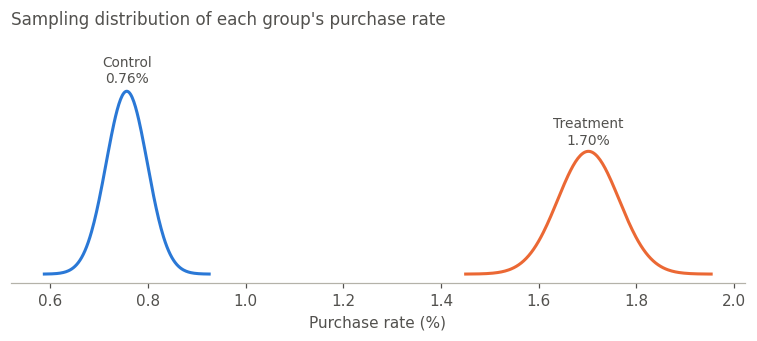

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
for label, p, n, color in [("Control", p_ctrl, n_ctrl, BLUE), ("Treatment", p_treat, n_treat, ORANGE)]:
    se = np.sqrt(p * (1 - p) / n)
    x = np.linspace(p - 4 * se, p + 4 * se, 200)
    ax.plot(x * 100, stats.norm.pdf(x, p, se), color=color, lw=2)
    ax.text(p * 100, stats.norm.pdf(p, p, se) * 1.03, f"{label}\n{p:.2%}", ha="center", va="bottom", color=INK, fontsize=9)
ax.set_xlabel("Purchase rate (%)")
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_ylim(top=ax.get_ylim()[1] * 1.25)
ax.set_title("Sampling distribution of each group's purchase rate", loc="left", color=INK)
fig.tight_layout()
plt.show()

Each curve shows the range the group's true purchase rate is likely to lie in, given the sample. The curves don't overlap at all, which already suggests the difference is not due to chance.

## 1.3 Is the effect statistically significant?

A **two-proportion z-test** compares the two purchase rates:

* **Null hypothesis (H₀):** the promotion has no effect, so both groups have the same purchase rate.
* **Alternative hypothesis (H₁):** the promotion increases the purchase rate (a one-sided test).
* **Significance level:** 5%. If the p-value is below 0.05, we reject H₀.

The test also gives a 95% **confidence interval**: the range the true uplift very likely falls in.

In [5]:
p_pool = summary.purchases.sum() / (n_ctrl + n_treat)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_ctrl + 1 / n_treat))
z = (p_treat - p_ctrl) / se_pool
p_value = stats.norm.sf(z)

uplift = p_treat - p_ctrl
se_diff = np.sqrt(p_treat * (1 - p_treat) / n_treat + p_ctrl * (1 - p_ctrl) / n_ctrl)
ci_low, ci_high = uplift - 1.96 * se_diff, uplift + 1.96 * se_diff

print(f"Uplift: {uplift * 100:.2f} percentage points (pp)")
print(f"95% confidence interval: {ci_low * 100:.2f} to {ci_high * 100:.2f} pp")
print(f"z = {z:.2f},  p-value = {p_value:.1e}")

Uplift: 0.95 percentage points (pp)
95% confidence interval: 0.80 to 1.09 pp
z = 12.47,  p-value = 5.5e-36


The p-value is essentially zero, so we reject H₀: **the promotion significantly increases purchases**, more than doubling the purchase rate from 0.76% to 1.70%.

## 1.4 Was the experiment large enough? (Power analysis)

A **power analysis** works out how many customers a test needs to reliably detect an effect of a given size. The standard targets are 80% power (an 80% chance of detecting a real effect) and a 5% significance level.

The effect size for two proportions is **Cohen's h**, and the required number of customers per group is

$$n = 2\left(\frac{z_{1-\alpha} + z_{1-\beta}}{h}\right)^2$$

The most useful effect to plan for is the **break-even uplift**. Each extra sale earns \$10 and each promotion costs \$0.15, so the promotion only pays for itself if it raises the purchase rate by at least 0.15 / 10 = **1.5 pp**.

In [6]:
def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

def sample_size_per_group(p_new, p_base, alpha=0.05, power=0.8):
    z_total = stats.norm.ppf(1 - alpha) + stats.norm.ppf(power)
    return int(np.ceil(2 * (z_total / cohens_h(p_new, p_base)) ** 2))

def minimum_detectable_effect(p_base, n, alpha=0.05, power=0.8):
    h = (stats.norm.ppf(1 - alpha) + stats.norm.ppf(power)) * np.sqrt(2 / n)
    return np.sin(h / 2 + np.arcsin(np.sqrt(p_base))) ** 2 - p_base

for label, effect in [("the observed uplift (0.95 pp)", uplift), ("the break-even uplift (1.5 pp)", 0.015)]:
    print(f"Customers needed per group to detect {label}: {sample_size_per_group(p_ctrl + effect, p_ctrl):,}")
print(f"Customers actually in each group: about {min(n_ctrl, n_treat):,}")
print(f"Smallest uplift this experiment can reliably detect: {minimum_detectable_effect(p_ctrl, min(n_ctrl, n_treat)) * 100:.2f} pp")

Customers needed per group to detect the observed uplift (0.95 pp): 1,616
Customers needed per group to detect the break-even uplift (1.5 pp): 762
Customers actually in each group: about 42,170
Smallest uplift this experiment can reliably detect: 0.16 pp


The experiment has about 26 times more customers than needed to detect the observed effect, and could detect an uplift as small as 0.16 pp. It is very well powered, so the result is reliable.

## 1.5 Is the promotion profitable?

Statistically significant does not mean profitable. The average uplift of 0.95 pp is below the 1.5 pp break-even, and so is the whole 95% confidence interval (0.80 to 1.09 pp). We can be confident that **sending the promotion to everyone loses money**, and the test set confirms it:

In [7]:
irr_all, nir_all = score(test)
print(f"Promote to everyone (test set):  IRR = {irr_all:.4f},  NIR = {nir_all:,.2f}")

Promote to everyone (test set):  IRR = 0.0096,  NIR = -1,132.20


**Conclusion of the A/B test:** the promotion works, but not well enough on average to cover its cost. It only makes sense if it is sent to the customers who respond best, which is what the model in Part 3 finds.

# Part 2: Exploring the Data

## 2.1 Class imbalance

The model will predict whether a customer buys. Purchases are rare, so the two classes (bought / didn't buy) are very unequal in size:

In [8]:
def imbalance(df):
    buyers = df.purchase.sum()
    return pd.Series({"customers": len(df), "buyers": buyers, "non-buyers": len(df) - buyers,
                      "non-buyers per buyer": round((len(df) - buyers) / buyers, 1)})

pd.DataFrame({"all training customers": imbalance(train),
              "promoted customers only": imbalance(train[train.Promotion == "Yes"])}).T

,customers,buyers,non-buyers,non-buyers per buyer
all training customers,84534.0,1040.0,83494.0,80.3
promoted customers only,42364.0,721.0,41643.0,57.8


Across all training customers there are about **80 non-buyers for every buyer**. The model is trained on promoted customers only (Part 3 explains why), where the ratio is about **58 to 1**.

This matters because most classifiers learn to maximise accuracy. With a 58:1 ratio, a model that predicts "won't buy" for everyone is already 98.3% accurate, so it has little reason to learn what buyers look like. Part 3 shows this happening, and fixes it with over-sampling.

## 2.2 Who responds to the promotion?

The chart shows the **uplift** for each value of each feature: the purchase rate of promoted customers minus that of control customers. The dashed line is the 1.5 pp break-even.

`V2` and `V3` are continuous, so customers are split into five equal-sized groups (**quintiles**): Q1 is the lowest 20% of values and Q5 the highest.

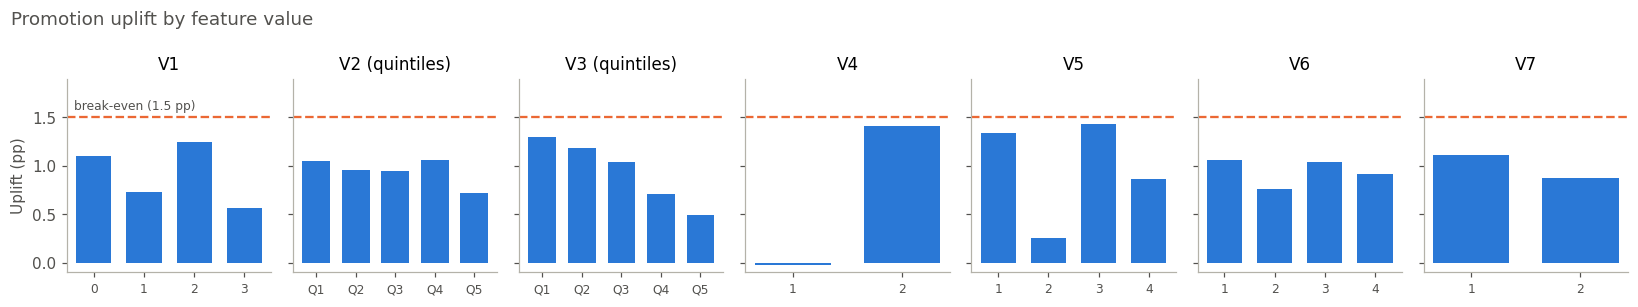

In [9]:
def uplift_by(df, col):
    groups = pd.qcut(df[col], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"]) if col in ("V2", "V3") else df[col]
    rates = df.groupby([groups, "Promotion"], observed=True).purchase.mean().unstack()
    return (rates["Yes"] - rates["No"]) * 100

fig, axes = plt.subplots(1, 7, figsize=(15, 2.8), sharey=True)
for ax, col in zip(axes, FEATURES):
    u = uplift_by(train, col)
    ax.bar(u.index.astype(str), u.values, color=BLUE, width=0.7)
    ax.axhline(1.5, color=ORANGE, ls="--", lw=1.5)
    ax.set_ylim(-0.1, 1.9)
    ax.set_title(col + (" (quintiles)" if col in ("V2", "V3") else ""))
    ax.tick_params(axis="x", labelsize=8)
axes[0].set_ylabel("Uplift (pp)")
axes[0].text(-0.4, 1.58, "break-even (1.5 pp)", color=INK, fontsize=8)
fig.suptitle("Promotion uplift by feature value", x=0.01, ha="left", color=INK)
fig.tight_layout()
plt.show()

**What this shows:**

* **V4** is the strongest signal. Customers with `V4 = 1` (about a third) don't respond to the promotion at all, while `V4 = 2` responds strongly.
* **V5** matters too: `V5 = 2` barely responds, while `V5 = 1` and `V5 = 3` respond strongly.
* **V3** has a trend: lower values respond more. The other features make little difference.
* No single feature clears the break-even line on its own, so the model needs to **combine** features to find the profitable customers.

# Part 3: Modelling

## 3.1 The approach: a response model

The model is a **gradient boosting classifier** trained on the **promoted customers only**, with `purchase` as the target. It learns what customers who buy *when promoted* look like, and gives every customer a probability of buying if they were sent the promotion. Customers above a chosen probability threshold are sent the promotion.

**Why only promoted customers?** The question is "who will buy if we promote them?". Control customers never saw the promotion, so they can't show how anyone responds to it.

**Why gradient boosting?** It builds many small decision trees, each correcting the errors of the previous ones. It handles a mix of categorical and continuous features, captures interactions (like V4 and V5 together) automatically, and performs strongly on tabular data. Shallow trees and large minimum leaf sizes keep it from overfitting, since there are only about 700 buyers to learn from. The settings are in `promotion.py`.

## 3.2 The class-imbalance problem

First, train the classifier **without** doing anything about the imbalance, and use the standard rule of predicting "will buy" when the probability is above 0.5:

In [10]:
promoted = train[train.Promotion == "Yes"]
baseline = fit_on_promoted(make_model(oversample=False), train)
p_baseline = baseline.predict_proba(promoted[FEATURES])[:, 1]

print(f"Customers predicted to buy (probability > 0.5): {(p_baseline > 0.5).sum()} of {len(promoted):,}")
print(f"Accuracy: {((p_baseline > 0.5) == promoted.purchase).mean():.1%}")
print(f"Highest predicted probability: {p_baseline.max():.3f}")

Customers predicted to buy (probability > 0.5): 0 of 42,364
Accuracy: 98.3%
Highest predicted probability: 0.044


The model is 98.3% accurate but **predicts that nobody will buy**, which is useless for targeting. Because buyers are so rare, the highest probability it gives any customer is far below 0.5.

## 3.3 Fixing it with SMOTE over-sampling

**Over-sampling** balances the classes by adding more examples of the rare class (buyers) to the training data. The simplest way is to duplicate existing buyers, but the model then just memorises those exact customers.

**SMOTE** (Synthetic Minority Over-sampling Technique) creates *new, synthetic* buyers instead:

1. Pick a real buyer.
2. Find the buyers most similar to them (their nearest neighbours).
3. Create a new customer part-way between the buyer and one of its neighbours.

This repeats until there are as many buyers as non-buyers. This dataset mixes categorical features (`V1`, `V4` to `V7`) and continuous ones (`V2`, `V3`). "Part-way between" category 1 and category 3 makes no sense, so the variant **SMOTE-NC** is used: it interpolates the continuous features and gives each synthetic customer the most common category among its neighbours.

**Important:** over-sampling must only be applied to the data the model is *trained* on, never to data it is *evaluated* on. Otherwise the evaluation would be scored partly on fake customers. Putting SMOTE-NC and the classifier together in an `imblearn` **pipeline** handles this automatically: over-sampling happens when the model is fitted, and new customers are scored as they are.

Here is what SMOTE-NC does to the training data:

In [11]:
smote = make_model().steps[0][1]
X_resampled, y_resampled = smote.fit_resample(promoted[FEATURES], promoted.purchase)
pd.DataFrame({"before SMOTE-NC": promoted.purchase.value_counts(),
              "after SMOTE-NC": pd.Series(y_resampled).value_counts()}).rename(index={0: "non-buyers", 1: "buyers"})

,before SMOTE-NC,after SMOTE-NC
purchase,,
non-buyers,41643,41643
buyers,721,41643


The 721 real buyers have been joined by about 41,000 synthetic ones, so the classes are now equal.

## 3.4 Comparing the two models

Both models are evaluated with **5-fold cross-validation** on the training data. The data is split into 5 parts; each model is trained on 4 parts and scores the customers in the 5th, rotating until every customer has been scored by a model that never saw them.

Two metrics measure how well each model **ranks** buyers above non-buyers, which accuracy can't do with imbalanced data:

* **ROC AUC:** the chance the model scores a random buyer higher than a random non-buyer (0.5 = random guessing, 1 = perfect).
* **Average precision:** how concentrated the buyers are among the top-scored customers (random guessing scores 0.017, the share of buyers).

In [12]:
cv_probs = cross_validated_scores(train, {
    "Gradient boosting, no over-sampling": lambda: make_model(oversample=False),
    "Gradient boosting + SMOTE-NC": make_model,
})

is_promoted = (train.Promotion == "Yes").to_numpy()
y_promoted = train.purchase.to_numpy()[is_promoted]
comparison = pd.DataFrame({
    name: {"ROC AUC": roc_auc_score(y_promoted, p[is_promoted]),
           "average precision": average_precision_score(y_promoted, p[is_promoted]),
           "average predicted probability": p[is_promoted].mean(),
           "share predicted to buy (p > 0.5)": (p[is_promoted] > 0.5).mean()}
    for name, p in cv_probs.items()}).T
comparison.round(3)

,ROC AUC,average precision,average predicted probability,share predicted to buy (p > 0.5)
"Gradient boosting, no over-sampling",0.652,0.027,0.017,0.000
Gradient boosting + SMOTE-NC,0.630,0.026,0.349,0.276


**What this shows:**

* **SMOTE-NC makes the model usable.** Without it, no customer gets a probability above 0.5. With it, the model flags about 28% of customers as likely buyers.
* **The ranking quality is similar, and slightly lower with SMOTE-NC** (ROC AUC 0.63 vs 0.65). SMOTE doesn't give the model new information; it changes how the model's scores are spread out, so the standard 0.5 cut-off becomes meaningful. The small drop in AUC is the price of training on synthetic customers.
* **The probabilities are inflated.** The model was trained on data where half the customers are buyers, so it predicts an average probability of about 35%, while the real purchase rate is 1.7%. The scores are useful for ranking and targeting customers, but shouldn't be read as real purchase probabilities.

## 3.5 Choosing the decision threshold

The model promotes customers whose probability is above a **threshold**. A lower threshold promotes more people. The best threshold is the one with the highest NIR.

To choose it without touching the test set, NIR is calculated from the cross-validated probabilities on the training data, for thresholds from 0.30 to 0.80. NIR is a total, so it grows with the number of customers; it is rescaled to the size of the test set so it can be compared with the benchmark.

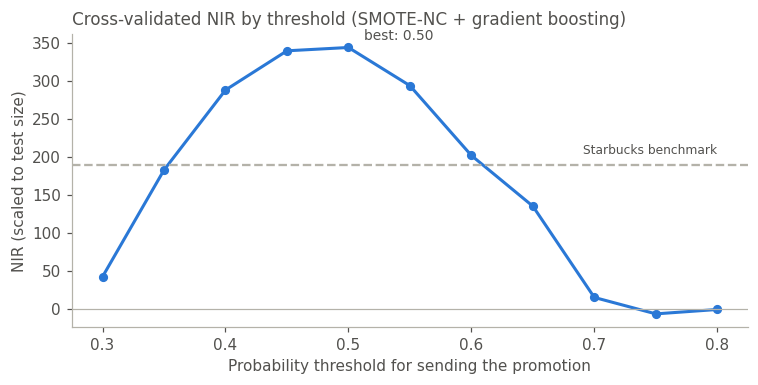

threshold,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80
cross-validated NIR,43.0,183.1,288.1,339.6,344.0,293.8,202.2,135.6,15.7,-5.8,-0.1


In [13]:
thresholds = np.round(np.arange(0.30, 0.801, 0.05), 2)
p_smote = cv_probs["Gradient boosting + SMOTE-NC"]
cv_nir = np.array([score(train[p_smote > t])[1] * len(test) / len(train) for t in thresholds])
best_threshold = thresholds[cv_nir.argmax()]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(thresholds, cv_nir, color=BLUE, marker="o", ms=5, lw=2)
ax.axhline(BENCHMARK_NIR, color=GREY, ls="--", lw=1.5)
ax.axhline(0, color=GREY, lw=0.8)
ax.text(0.8, BENCHMARK_NIR + 15, "Starbucks benchmark", color=INK, ha="right", fontsize=8)
ax.annotate(f"best: {best_threshold:.2f}", (best_threshold, cv_nir.max()), xytext=(10, 5),
            textcoords="offset points", color=INK, fontsize=9)
ax.set_xlabel("Probability threshold for sending the promotion")
ax.set_ylabel("NIR (scaled to test size)")
ax.set_title("Cross-validated NIR by threshold (SMOTE-NC + gradient boosting)", loc="left", color=INK)
fig.tight_layout()
plt.show()

pd.DataFrame({"threshold": thresholds, "cross-validated NIR": cv_nir.round(1)}).set_index("threshold").T

NIR peaks at a threshold of **0.50**, the standard default. This is a direct benefit of balancing the classes: because SMOTE-NC trained the model on a 50/50 split, "more likely to buy than not" lines up with the most profitable cut-off. Lower thresholds promote customers who don't respond enough to cover the cost; higher thresholds miss profitable ones.

# Part 4: Test Set Results

The final model is trained on all promoted customers in the training set, uses the 0.50 threshold chosen above, and is scored on the test set for the first and only time.

In [14]:
model = fit_on_promoted(make_model(), train)
strategy = promotion_strategy(model, best_threshold)
irr, nir = test_results(strategy, test)
share = (strategy(test) == "Yes").mean()

pd.DataFrame({"share promoted": ["100%", "–", f"{share:.0%}"],
              "IRR": [f"{irr_all:.4f}", f"{BENCHMARK_IRR:.4f}", f"{irr:.4f}"],
              "NIR": [f"{nir_all:,.2f}", f"{BENCHMARK_NIR:,.2f}", f"{nir:,.2f}"]},
             index=["Promote to everyone", "Starbucks benchmark", "SMOTE-NC + gradient boosting"])

,share promoted,IRR,NIR
Promote to everyone,100%,0.0096,"-1,132.20"
Starbucks benchmark,–,0.0188,189.45
SMOTE-NC + gradient boosting,28%,0.0207,320.00


By promoting only the 28% of customers the model identifies as likely responders, NIR goes from a **\$1,132 loss** to a **\$320 profit**, about 1.7 times the Starbucks benchmark. IRR rises from 0.0096 to 0.0207: among the targeted customers, the promotion raises the purchase rate by 2.07 pp, comfortably above the 1.5 pp break-even.

## 4.1 Which features drive the model?

**Permutation importance** measures how much a feature matters by randomly shuffling its values and seeing how much the model's performance (here, ROC AUC on promoted test customers) drops. A big drop means the model relies heavily on that feature.

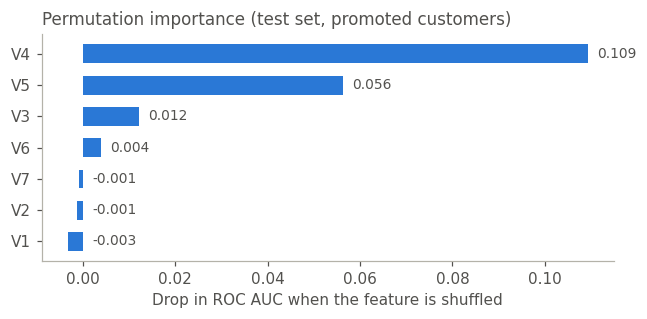

In [15]:
promoted_test = test[test.Promotion == "Yes"]
imp = permutation_importance(model, promoted_test[FEATURES], promoted_test.purchase,
                             scoring="roc_auc", n_repeats=10, random_state=0)
importance = pd.Series(imp.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(importance.index, importance.values, color=BLUE, height=0.6)
for i, v in enumerate(importance.values):
    ax.text(max(v, 0) + 0.002, i, f"{v:.3f}", va="center", color=INK, fontsize=9)
ax.set_xlabel("Drop in ROC AUC when the feature is shuffled")
ax.set_title("Permutation importance (test set, promoted customers)", loc="left", color=INK)
fig.tight_layout()
plt.show()

The model relies mostly on **V4** and **V5**, the same features that stood out in the uplift chart in Part 2, with a smaller contribution from **V3**. The other features contribute almost nothing: values near zero (or slightly below it) mean shuffling the feature made no real difference.

# Conclusions

* **The A/B test is valid and conclusive.** Randomisation was fair, the experiment was very well powered, and the promotion significantly increased purchases (0.76% → 1.70%, p < 0.001).
* **Significant is not the same as profitable.** The average uplift of 0.95 pp is below the 1.5 pp needed to cover the promotion's cost, so promoting everyone loses \$1,132 on the test set.
* **Class imbalance had to be addressed.** Without over-sampling, the gradient boosting classifier predicted no buyers at all. SMOTE-NC balanced the classes so the model makes useful predictions, and the standard 0.5 threshold turned out to be the most profitable.
* **Targeting pays.** Promoting only the 28% of customers the model picks gives **IRR 0.0207 and NIR \$320**, beating the Starbucks benchmark.

## Limitations and next steps

* **A response model predicts who buys when promoted, not who buys *because* of the promotion.** Some targeted customers would have bought anyway. **Uplift modelling** (for example a T-learner, which trains separate models on promoted and control customers and compares their predictions) targets the extra buyers directly, and would be the natural next step.
* **SMOTE inflates the predicted probabilities**, so they are useful for ranking customers but aren't real purchase probabilities. Class weights are an alternative way to handle imbalance without creating synthetic data.
* **The features are anonymised**, so the customer groups the model picks can't be described in business terms.